# ***ĐỒ ÁN 2***

In [ ]:
# Google Colab chỉ dùng khi chạy trên Colab
# from google.colab import drive
# drive.mount('/content/drive')

# Kiểm tra xem đã thấy file chưa
import os
path = r'd:\Project_2\DoAn2\data'  # Đường dẫn Windows
print(os.listdir(path))

Mounted at /content/drive
['Video_Games.jsonl.gz', 'meta_Video_Games.jsonl.gz', 'DoAn2.ipynb']


In [ ]:
# Sửa lại đúng tên file trong Drive của bạn
INTERACTION_FILE = r'd:\Project_2\DoAn2\data\Video_Games.jsonl.gz'
META_FILE = r'd:\Project_2\DoAn2\data\meta_Video_Games.jsonl.gz'

In [ ]:
# Cell 0.1 — Cài thư viện (chạy 1 lần)
# !pip install torch pandas numpy matplotlib seaborn tqdm scikit-learn fastapi uvicorn requests

In [ ]:
import warnings
warnings.filterwarnings('ignore')
# Cell 0.2 — Import
import gzip, json, pickle, os, math, random
from collections import defaultdict, Counter
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.sparse import lil_matrix
from sklearn.metrics.pairwise import cosine_similarity
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (12, 4),
                     'axes.titlesize': 13, 'axes.labelsize': 11})

In [ ]:
# Cell 0.3 — Seed & Device
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device  : {DEVICE}')
print(f'✅ PyTorch : {torch.__version__}')

✅ Device  : cuda
✅ PyTorch : 2.9.0+cu126


In [ ]:
# Cell 0.4 — Tạo thư mục
for d in ['data', 'checkpoints', 'outputs', 'api']:
    os.makedirs(d, exist_ok=True)
print('✅ Tạo thư mục: data/ checkpoints/ outputs/ api/')

✅ Tạo thư mục: data/ checkpoints/ outputs/ api/


---
# 📥 1. Đọc Dataset

In [ ]:
# Cell 1.1 — Khai báo đường dẫn file
REVIEW_FILE = r'd:\Project_2\DoAn2\data\Video_Games.jsonl.gz'
META_FILE   = r'd:\Project_2\DoAn2\data\meta_Video_Games.jsonl.gz'

print(f'Review file : {REVIEW_FILE}  (exists={os.path.exists(REVIEW_FILE)})')
print(f'Meta file   : {META_FILE}  (exists={os.path.exists(META_FILE)})')

Review file : /content/drive/MyDrive/DoAn2/Video_Games.jsonl.gz  (exists=True)
Meta file   : /content/drive/MyDrive/DoAn2/meta_Video_Games.jsonl.gz  (exists=True)


In [ ]:
# Cell 1.2 — Đọc file Review (.jsonl.gz)
def load_reviews(path):
    records = []
    opener  = gzip.open if path.endswith('.gz') else open
    with opener(path, 'rt', encoding='utf-8') as f:
        for line in tqdm(f, desc='Reading reviews'):
            try:
                r = json.loads(line)
                records.append({
                    'user_id'  : r.get('user_id')   or r.get('reviewerID'),
                    'item_id'  : r.get('parent_asin') or r.get('asin'),
                    'rating'   : float(r.get('rating', r.get('overall', 0))),
                    'timestamp': int(r.get('timestamp', r.get('unixReviewTime', 0))),
                })
            except: pass
    return pd.DataFrame(records).dropna()

df_reviews = load_reviews(REVIEW_FILE)
print(f'\n✅ Rows: {len(df_reviews):,}')
print(f'   Columns: {list(df_reviews.columns)}')

Reading reviews: 0it [00:00, ?it/s]


✅ Rows: 4,624,615
   Columns: ['user_id', 'item_id', 'rating', 'timestamp']


In [ ]:
# Cell 1.3 — Xem vài dòng đầu reviews
df_reviews.head(10)

,user_id,item_id,rating,timestamp
0,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B07DK1H3H5,4.0,1608186804795
1,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B07SRWRH5D,5.0,1587051114941
2,AGXVBIUFLFGMVLATYXHJYL4A5Q7Q,B07MFMFW34,5.0,1490877431000
3,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,B0BCHWZX95,5.0,1577637634017
4,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,B00HUWA45W,5.0,1427591932000
5,AHXSBZT52TCPZUBVCBRICTHWUCBA,B073SC6V1D,3.0,1518124539574
6,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,B004RMK57U,5.0,1602937709361
7,AFO6QN6ICKWUFQV3UEWK5EECIQTQ,B0BYVN9ZK2,5.0,1602718512453
8,AG6BAEKWLCWH2TW3KKLVK773YF6A,B08L6782X9,5.0,1621448670253
9,AG6BAEKWLCWH2TW3KKLVK773YF6A,B017V6YVDC,1.0,1607734474794


In [ ]:
# Cell 1.4 — Đọc file Metadata sản phẩm
def load_metadata(path):
    meta = {}
    opener = gzip.open if path.endswith('.gz') else open
    with opener(path, 'rt', encoding='utf-8') as f:
        for line in tqdm(f, desc='Reading metadata'):
            try:
                m    = json.loads(line)
                asin = m.get('parent_asin') or m.get('asin')
                if not asin: continue
                cats = m.get('categories', []) or m.get('category', [])
                cat  = cats[-1] if cats and isinstance(cats[-1], str) else 'Unknown'
                try:   price = float(str(m.get('price', 0)).replace('$','').replace(',',''))
                except: price = 0.0
                meta[asin] = {
                    'title'      : str(m.get('title', ''))[:80],
                    'category'   : str(cat)[:40],
                    'price'      : price,
                    'avg_rating' : float(m.get('average_rating', 0)),
                    'img_url'    : (m.get('images') or [{}])[0].get('large','') if m.get('images') else '',
                }
            except: pass
    return meta

meta = load_metadata(META_FILE)
print(f'\n✅ Metadata: {len(meta):,} sản phẩm')

Reading metadata: 0it [00:00, ?it/s]


✅ Metadata: 137,269 sản phẩm


In [ ]:
# Cell 1.5 — Gắn category & title vào df_reviews
df_reviews['category'] = df_reviews['item_id'].map(
    lambda x: meta.get(x, {}).get('category', 'Unknown'))
df_reviews['title']    = df_reviews['item_id'].map(
    lambda x: meta.get(x, {}).get('title', x))

print('✅ Đã gắn category và title')
df_reviews[['user_id','item_id','rating','timestamp','category','title']].head(5)

✅ Đã gắn category và title


,user_id,item_id,rating,timestamp,category,title
0,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B07DK1H3H5,4.0,1608186804795,Games,Cyberpunk 2077 - PC [Game Download Code in Box]
1,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B07SRWRH5D,5.0,1587051114941,Games,Final Fantasy VII: Remake - PlayStation 4
2,AGXVBIUFLFGMVLATYXHJYL4A5Q7Q,B07MFMFW34,5.0,1490877431000,Games,Sid Meier’s Civilization VI: Rise and Fall [On...
3,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,B0BCHWZX95,5.0,1577637634017,Controllers,PowerA Enhanced Wireless Controller for Ninten...
4,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,B00HUWA45W,5.0,1427591932000,Accessories,KontrolFreek FPS Freek CQC Signature - Xbox One


In [ ]:
print(df_reviews["timestamp"].max())
print(df_reviews["timestamp"].min())

1694509355529
911332729000


In [ ]:
df_reviews["timestamp"] = pd.to_datetime(df_reviews["timestamp"], unit="ms")

In [ ]:
# Cell 1.6 — Thống kê tổng quan dataset gốc
n_users = df_reviews['user_id'].nunique()
n_items = df_reviews['item_id'].nunique()
n_inter = len(df_reviews)
sparsity = 1 - n_inter / (n_users * n_items)

print('━'*50)
print('  RAW DATASET STATISTICS')
print('━'*50)
print(f'  Interactions  : {n_inter:>12,}')
print(f'  Users         : {n_users:>12,}')
print(f'  Items         : {n_items:>12,}')
print(f'  Avg rating    : {df_reviews["rating"].mean():>12.2f}')
print(f'  Sparsity      : {sparsity:>12.4%}')
ts_min = pd.to_datetime(df_reviews['timestamp'].min(), unit='s').date()
ts_max = pd.to_datetime(df_reviews['timestamp'].max(), unit='s').date()
print(f'  Time range    : {ts_min} → {ts_max}')
print('━'*50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RAW DATASET STATISTICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Interactions  :    4,624,615
  Users         :    2,766,656
  Items         :      137,249
  Avg rating    :         4.05
  Sparsity      :     99.9988%
  Time range    : 1998-11-17 → 2023-09-12
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
# 📊 2. EDA — Khám phá dữ liệu

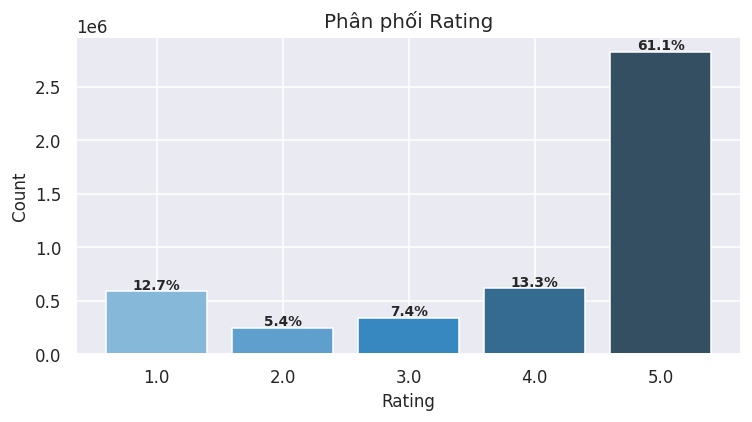

rating
1.0     589519
2.0     249878
3.0     340086
4.0     617251
5.0    2827881


In [ ]:
# Cell 2.1 — Phân phối Rating
fig, ax = plt.subplots(figsize=(7, 4))
rating_cnt = df_reviews['rating'].value_counts().sort_index()
bars = ax.bar(rating_cnt.index.astype(str), rating_cnt.values,
              color=sns.color_palette('Blues_d', 5), edgecolor='white')
for bar, v in zip(bars, rating_cnt.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+n_inter*0.004,
            f'{v/n_inter:.1%}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Phân phối Rating')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/01_rating_dist.png', bbox_inches='tight')
plt.show()
print(rating_cnt.to_string())

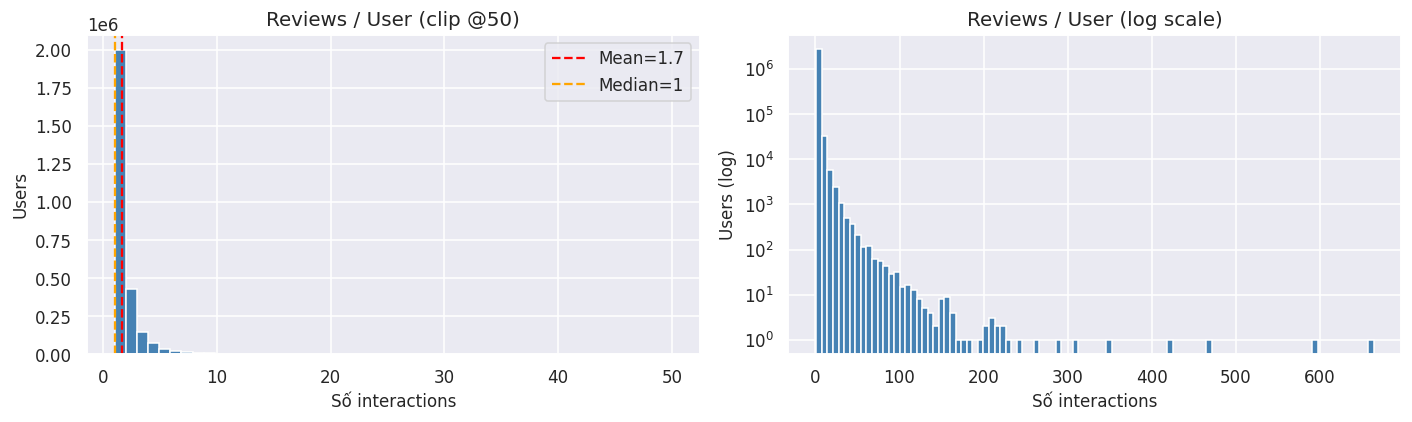

count    2.766656e+06
mean     1.671554e+00
std      2.418684e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      6.640000e+02
dtype: float64


In [ ]:
# Cell 2.2 — Số reviews mỗi User
user_cnt = df_reviews.groupby('user_id').size()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(user_cnt.clip(upper=50), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(user_cnt.mean(),   color='red',    ls='--', label=f'Mean={user_cnt.mean():.1f}')
axes[0].axvline(user_cnt.median(), color='orange', ls='--', label=f'Median={user_cnt.median():.0f}')
axes[0].set_title('Reviews / User (clip @50)')
axes[0].set_xlabel('Số interactions'); axes[0].set_ylabel('Users')
axes[0].legend()

axes[1].hist(user_cnt, bins=100, color='steelblue', edgecolor='white', log=True)
axes[1].set_title('Reviews / User (log scale)')
axes[1].set_xlabel('Số interactions'); axes[1].set_ylabel('Users (log)')

plt.tight_layout()
plt.savefig('outputs/02_user_dist.png', bbox_inches='tight')
plt.show()
print(user_cnt.describe())

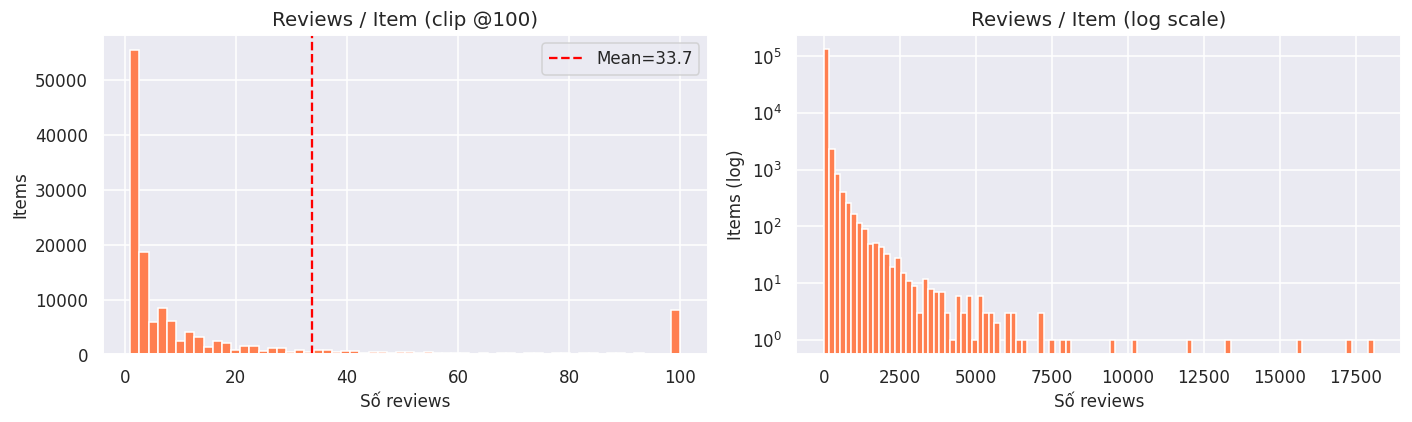

count    137249.000000
mean         33.695072
std         200.255407
min           1.000000
25%           1.000000
50%           4.000000
75%          14.000000
max       18105.000000
dtype: float64


In [ ]:
# Cell 2.3 — Số reviews mỗi Item
item_cnt = df_reviews.groupby('item_id').size()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(item_cnt.clip(upper=100), bins=60, color='coral', edgecolor='white')
axes[0].axvline(item_cnt.mean(), color='red', ls='--', label=f'Mean={item_cnt.mean():.1f}')
axes[0].set_title('Reviews / Item (clip @100)')
axes[0].set_xlabel('Số reviews'); axes[0].set_ylabel('Items')
axes[0].legend()

axes[1].hist(item_cnt, bins=100, color='coral', edgecolor='white', log=True)
axes[1].set_title('Reviews / Item (log scale)')
axes[1].set_xlabel('Số reviews'); axes[1].set_ylabel('Items (log)')

plt.tight_layout()
plt.savefig('outputs/03_item_dist.png', bbox_inches='tight')
plt.show()
print(item_cnt.describe())

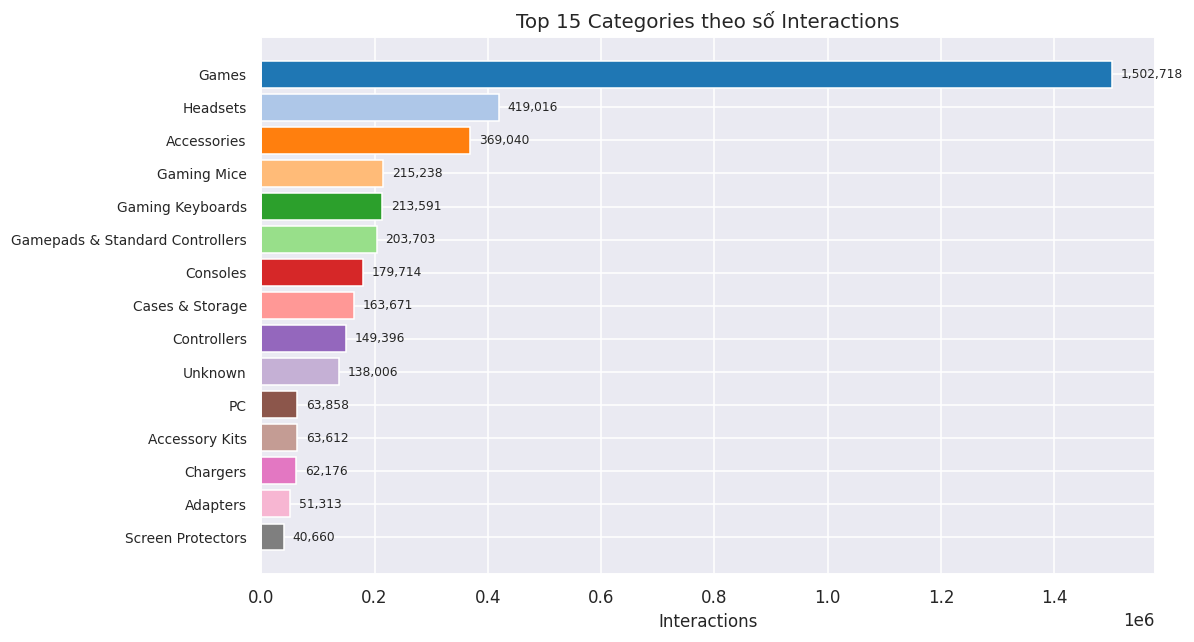

In [ ]:
# Cell 2.4 — Top 15 Categories
top_cats = df_reviews['category'].value_counts().head(15)
fig, ax  = plt.subplots(figsize=(11, 6))
bars = ax.barh(range(len(top_cats)), top_cats.values,
               color=sns.color_palette('tab20', 15), edgecolor='white')
ax.set_yticks(range(len(top_cats)))
ax.set_yticklabels(top_cats.index, fontsize=9)
ax.invert_yaxis()
for bar, v in zip(bars, top_cats.values):
    ax.text(v + top_cats.max()*0.01, bar.get_y()+bar.get_height()/2,
            f'{v:,}', va='center', fontsize=8)
ax.set_title('Top 15 Categories theo số Interactions')
ax.set_xlabel('Interactions')
plt.tight_layout()
plt.savefig('outputs/04_top_categories.png', bbox_inches='tight')
plt.show()

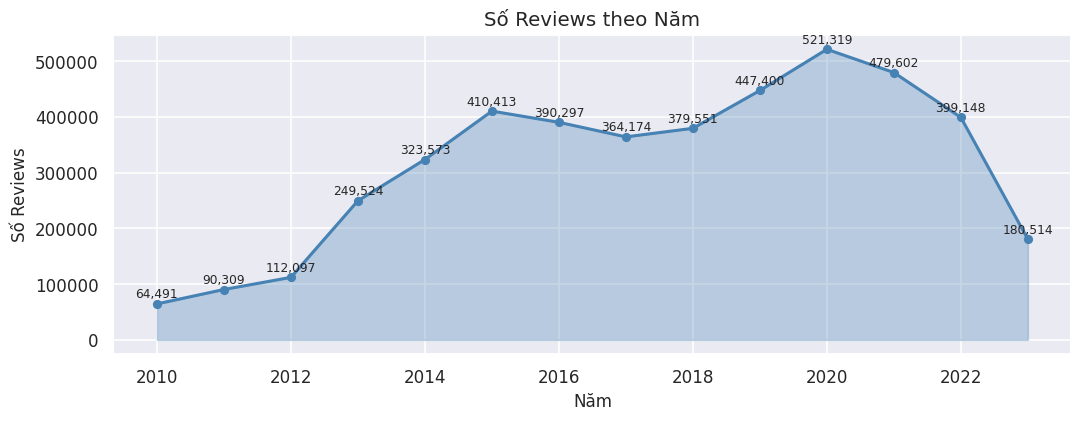

In [ ]:
# Cell 2.5 — Reviews theo năm (timeline)
df_reviews['year'] = pd.to_datetime(df_reviews['timestamp'], unit='s').dt.year
yearly = df_reviews.groupby('year').size().reset_index(name='count')
yearly = yearly[(yearly['year'] >= 2010) & (yearly['year'] <= 2023)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(yearly['year'], yearly['count'], alpha=0.3, color='steelblue')
ax.plot(yearly['year'], yearly['count'], 'o-', color='steelblue', linewidth=2, markersize=5)
for _, row in yearly.iterrows():
    ax.text(row['year'], row['count']+yearly['count'].max()*0.02,
            f"{int(row['count']):,}", ha='center', fontsize=8)
ax.set_title('Số Reviews theo Năm')
ax.set_xlabel('Năm'); ax.set_ylabel('Số Reviews')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('outputs/05_reviews_timeline.png', bbox_inches='tight')
plt.show()

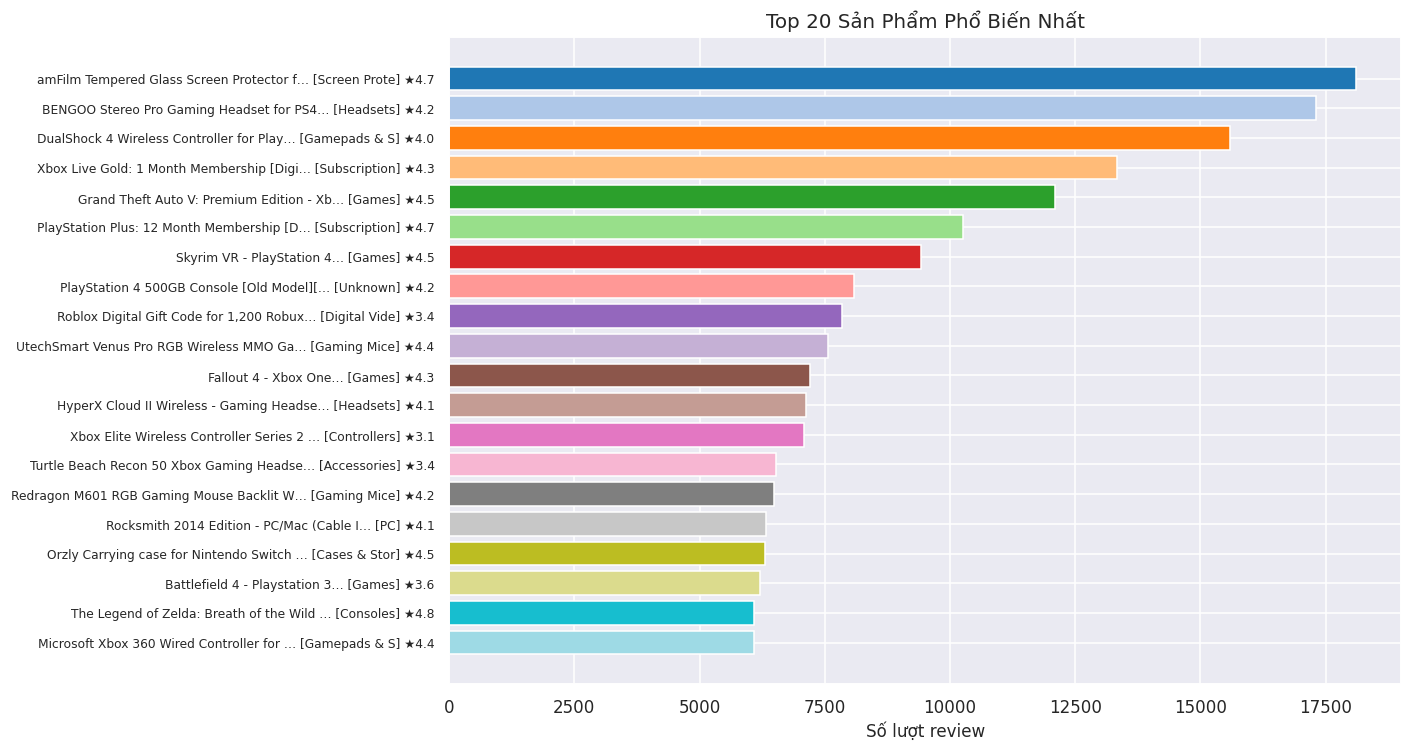

In [ ]:
# Cell 2.6 — Top 20 sản phẩm phổ biến nhất
top_items_eda = (
    df_reviews.groupby('item_id')
    .agg(count=('user_id','count'), avg_rating=('rating','mean'),
         title=('title','first'), category=('category','first'))
    .sort_values('count', ascending=False).head(20).reset_index()
)
fig, ax = plt.subplots(figsize=(13, 7))
colors_p = sns.color_palette('tab20', 20)
bars = ax.barh(range(20), top_items_eda['count'], color=colors_p, edgecolor='white')
labels = [f"{r['title'][:40]}… [{r['category'][:12]}] ★{r['avg_rating']:.1f}"
          for _, r in top_items_eda.iterrows()]
ax.set_yticks(range(20)); ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_title('Top 20 Sản Phẩm Phổ Biến Nhất')
ax.set_xlabel('Số lượt review')
plt.tight_layout()
plt.savefig('outputs/06_top_items.png', bbox_inches='tight')
plt.show()

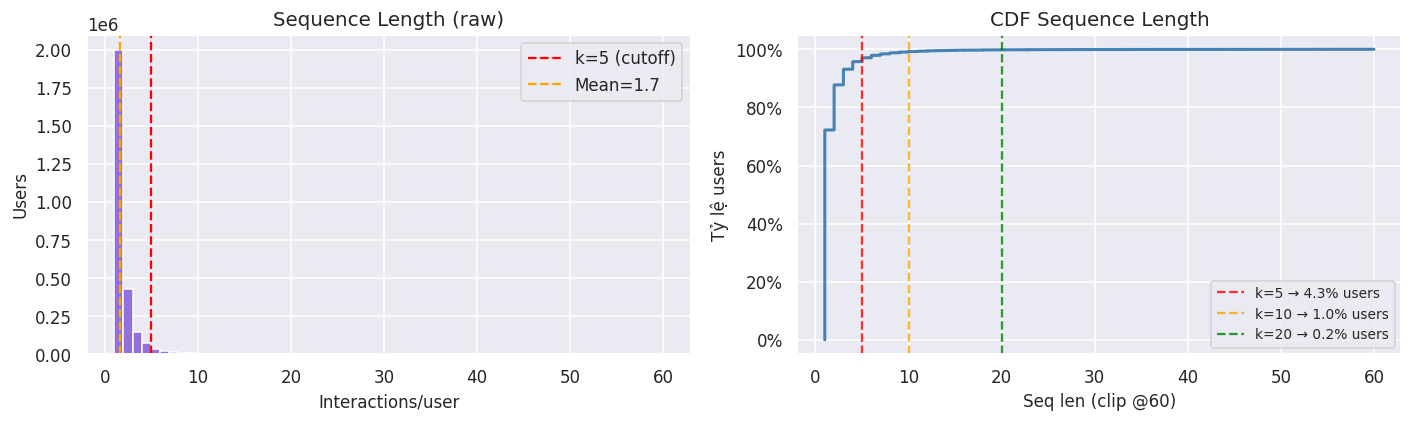

  25th pct: 1 interactions/user
  50th pct: 1 interactions/user
  75th pct: 2 interactions/user
  90th pct: 3 interactions/user
  95th pct: 4 interactions/user
  99th pct: 9 interactions/user


In [ ]:
# Cell 2.7 — Sequence Length Distribution
seq_lens_raw = df_reviews.groupby('user_id').size()
fig, axes   = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(seq_lens_raw.clip(upper=60), bins=60, color='mediumpurple', edgecolor='white', lw=0.3)
axes[0].axvline(5,  color='red',    ls='--', lw=1.5, label='k=5 (cutoff)')
axes[0].axvline(seq_lens_raw.mean(), color='orange', ls='--', label=f'Mean={seq_lens_raw.mean():.1f}')
axes[0].set_title('Sequence Length (raw)'); axes[0].set_xlabel('Interactions/user')
axes[0].set_ylabel('Users'); axes[0].legend()

sorted_l = np.sort(seq_lens_raw.values)
cdf      = np.arange(1, len(sorted_l)+1)/len(sorted_l)
axes[1].plot(sorted_l.clip(max=60), cdf, color='steelblue', lw=2)
for k_val, c in [(5,'red'),(10,'orange'),(20,'green')]:
    pct = (seq_lens_raw >= k_val).mean()
    axes[1].axvline(k_val, color=c, ls='--', alpha=0.8, label=f'k={k_val} → {pct:.1%} users')
axes[1].set_title('CDF Sequence Length'); axes[1].set_xlabel('Seq len (clip @60)')
axes[1].set_ylabel('Tỷ lệ users'); axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig('outputs/07_seq_length.png', bbox_inches='tight')
plt.show()

for p in [25, 50, 75, 90, 95, 99]:
    print(f'  {p}th pct: {np.percentile(seq_lens_raw, p):.0f} interactions/user')

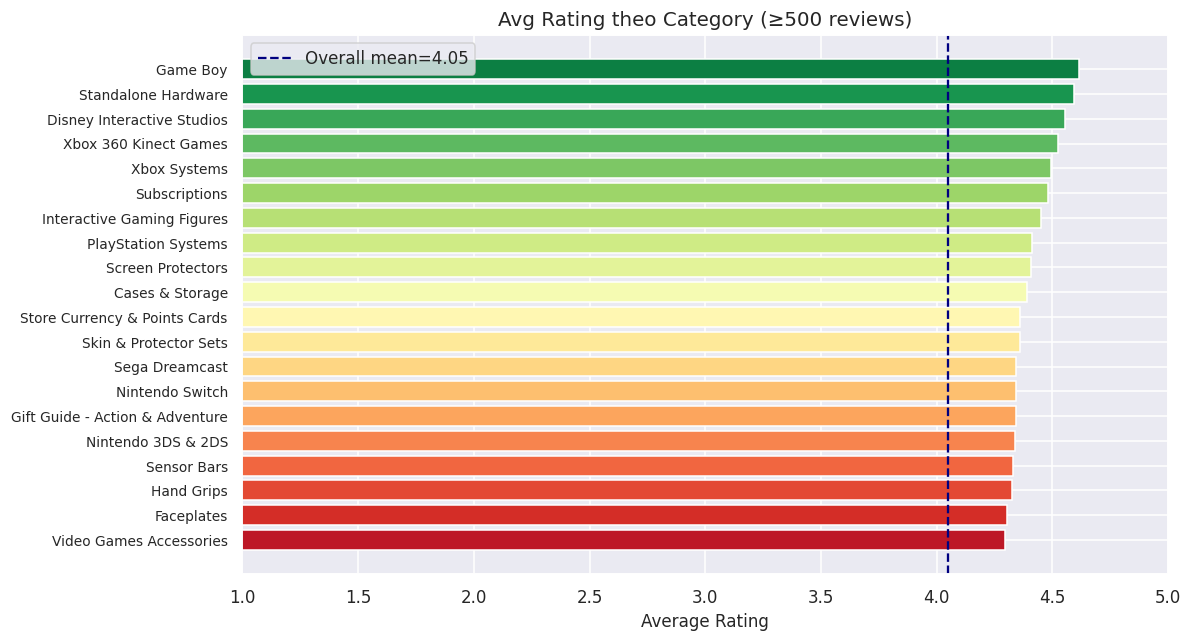

In [ ]:
# Cell 2.8 — Rating trung bình theo Category
cat_stats = (
    df_reviews.groupby('category')
    .agg(count=('user_id','count'), avg_rating=('rating','mean'))
    .query('count >= 500')
    .sort_values('avg_rating', ascending=False)
    .head(20)
)
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(range(len(cat_stats)), cat_stats['avg_rating'],
               color=sns.color_palette('RdYlGn', len(cat_stats))[::-1], edgecolor='white')
ax.set_yticks(range(len(cat_stats)))
ax.set_yticklabels(cat_stats.index, fontsize=9)
ax.invert_yaxis()
ax.axvline(df_reviews['rating'].mean(), color='navy', ls='--', lw=1.5,
           label=f'Overall mean={df_reviews["rating"].mean():.2f}')
ax.set_xlim(1, 5); ax.set_title('Avg Rating theo Category (≥500 reviews)')
ax.set_xlabel('Average Rating'); ax.legend()
plt.tight_layout()
plt.savefig('outputs/08_rating_by_category.png', bbox_inches='tight')
plt.show()

---
# 🔧 3. Data Preprocessing

In [ ]:
# Cell 3.1 — Khai báo hyperparameter preprocessing
K_CORE  = 5     # Giữ user/item có ít nhất K interactions
MAX_LEN = 50    # Độ dài tối đa của sequence
NUM_NEG = 99    # Số negative items khi evaluate
print(f'K_CORE  = {K_CORE}')
print(f'MAX_LEN = {MAX_LEN}')
print(f'NUM_NEG = {NUM_NEG}')

K_CORE  = 5
MAX_LEN = 50
NUM_NEG = 99


In [ ]:
# Cell 3.2 — K-core Filtering
def k_core_filter(df, k=5):
    df = df.copy()
    it = 0
    while True:
        prev = len(df)
        # Lọc item có < k reviews
        ic = df['item_id'].value_counts()
        df = df[df['item_id'].isin(ic[ic >= k].index)]
        # Lọc user có < k reviews
        uc = df['user_id'].value_counts()
        df = df[df['user_id'].isin(uc[uc >= k].index)]
        it += 1
        if len(df) == prev: break
    return df.reset_index(drop=True), it

print(f'Trước filter: {len(df_reviews):,} interactions')
df, n_iter = k_core_filter(df_reviews, k=K_CORE)
print(f'Sau {K_CORE}-core  ({n_iter} vòng): {len(df):,} interactions')
print(f'  Users: {df_reviews["user_id"].nunique():,} → {df["user_id"].nunique():,}')
print(f'  Items: {df_reviews["item_id"].nunique():,} → {df["item_id"].nunique():,}')
print(f'  Giảm : {(1-len(df)/len(df_reviews)):.1%} interactions')

Trước filter: 4,624,615 interactions
Sau 5-core  (8 vòng): 857,505 interactions
  Users: 2,766,656 → 98,906
  Items: 137,249 → 26,354
  Giảm : 81.5% interactions


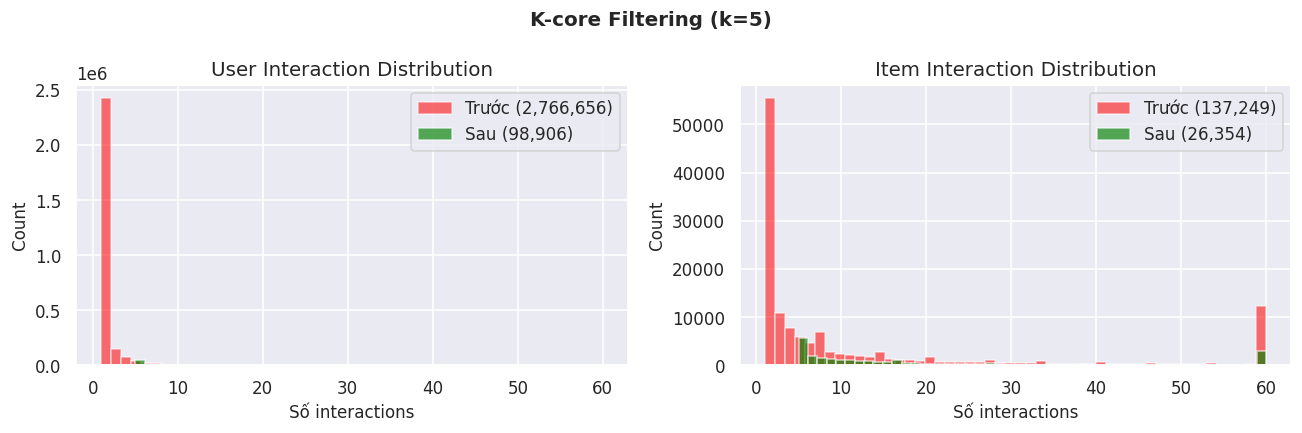

In [ ]:
# Cell 3.3 — So sánh trước/sau K-core (biểu đồ)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels    = ['Trước K-core', f'Sau {K_CORE}-core']

for ax, col, title in [
    (axes[0], 'user_id', 'User'),
    (axes[1], 'item_id', 'Item'),
]:
    before = df_reviews.groupby(col).size()
    after  = df.groupby(col).size()
    ax.hist(before.clip(upper=60), bins=50, alpha=0.55, color='red',   label=f'Trước ({len(before):,})')
    ax.hist(after.clip(upper=60),  bins=50, alpha=0.65, color='green', label=f'Sau ({len(after):,})')
    ax.set_title(f'{title} Interaction Distribution')
    ax.set_xlabel('Số interactions')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle(f'K-core Filtering (k={K_CORE})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/09_kcore_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
# Cell 3.4 — Encode User ID & Item ID (bắt đầu từ 1, 0 dành cho padding)
users = sorted(df['user_id'].unique())
items = sorted(df['item_id'].unique())

user2id = {u: i+1 for i, u in enumerate(users)}
item2id = {it: i+1 for i, it in enumerate(items)}
id2user = {v: k for k, v in user2id.items()}
id2item = {v: k for k, v in item2id.items()}

df['user'] = df['user_id'].map(user2id)
df['item'] = df['item_id'].map(item2id)

NUM_USERS = len(users)
NUM_ITEMS = len(items)
print(f'✅ NUM_USERS = {NUM_USERS:,}  (ID: 1 → {NUM_USERS})')
print(f'✅ NUM_ITEMS = {NUM_ITEMS:,}  (ID: 1 → {NUM_ITEMS}, 0=padding)')

✅ NUM_USERS = 98,906  (ID: 1 → 98906)
✅ NUM_ITEMS = 26,354  (ID: 1 → 26354, 0=padding)


In [ ]:
# Cell 3.5 — Sắp xếp theo timestamp → tạo user sequences
df_sorted        = df.sort_values(['user','timestamp'])
user_sequences   = df_sorted.groupby('user')['item'].apply(list).to_dict()

seq_lens = [len(v) for v in user_sequences.values()]
print(f'✅ Số sequences  : {len(user_sequences):,}')
print(f'   Độ dài TB     : {np.mean(seq_lens):.2f}')
print(f'   Độ dài Min/Max: {min(seq_lens)} / {max(seq_lens)}')
print(f'\nVí dụ sequence user=1: {user_sequences[1][:10]}...')

✅ Số sequences  : 98,906
   Độ dài TB     : 8.67
   Độ dài Min/Max: 5 / 594

Ví dụ sequence user=1: [20763, 19812, 15241, 19623, 25812]...


In [ ]:
# Cell 3.6 — Leave-One-Out Split
#
#   [i1, i2, ..., iN-2 | iN-1 | iN]
#    ←──── Train ──────   Val    Test

train_data, val_data, test_data = {}, {}, {}

for user, seq in user_sequences.items():
    if len(seq) < 3: continue    # cần ít nhất 3 items
    train_data[user] = seq[:-2]
    val_data[user]   = seq[-2]   # 1 item val
    test_data[user]  = seq[-1]   # 1 item test

print(f'Train users: {len(train_data):,}')
print(f'Val   users: {len(val_data):,}')
print(f'Test  users: {len(test_data):,}')

# Xem thử 1 user
sample_u = list(train_data.keys())[0]
print(f'\nUser {sample_u}:')
print(f'  Train seq : {train_data[sample_u]}')
print(f'  Val item  : {val_data[sample_u]}')
print(f'  Test item : {test_data[sample_u]}')

Train users: 98,906
Val   users: 98,906
Test  users: 98,906

User 1:
  Train seq : [20763, 19812, 15241]
  Val item  : 19623
  Test item : 25812


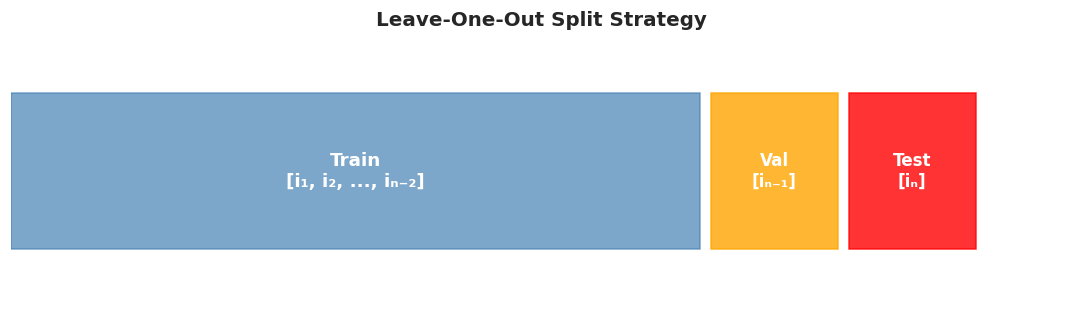

In [ ]:
# Cell 3.7 — Visualize split strategy
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_xlim(0, 10); ax.set_ylim(0, 1); ax.axis('off')

# Train block
train_rect = plt.Rectangle((0, 0.2), 6.5, 0.6, color='steelblue', alpha=0.7)
val_rect   = plt.Rectangle((6.6, 0.2), 1.2, 0.6, color='orange',  alpha=0.8)
test_rect  = plt.Rectangle((7.9, 0.2), 1.2, 0.6, color='red',     alpha=0.8)

for rect in [train_rect, val_rect, test_rect]:
    ax.add_patch(rect)

ax.text(3.25, 0.50, 'Train\n[i₁, i₂, ..., iₙ₋₂]', ha='center', va='center',
        fontsize=12, fontweight='bold', color='white')
ax.text(7.20, 0.50, 'Val\n[iₙ₋₁]', ha='center', va='center',
        fontsize=11, fontweight='bold', color='white')
ax.text(8.50, 0.50, 'Test\n[iₙ]', ha='center', va='center',
        fontsize=11, fontweight='bold', color='white')

ax.set_title('Leave-One-Out Split Strategy', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('outputs/10_split_strategy.png', bbox_inches='tight')
plt.show()

In [ ]:
# Cell 3.8 — Lưu processed data
processed = {
    'train': train_data, 'val': val_data, 'test': test_data,
    'user2id': user2id, 'item2id': item2id,
    'id2user': id2user, 'id2item': id2item,
    'num_users': NUM_USERS, 'num_items': NUM_ITEMS,
    'meta': meta,
}
with open('data/processed.pkl', 'wb') as f:
    pickle.dump(processed, f)
print('✅ Đã lưu → data/processed.pkl')

✅ Đã lưu → data/processed.pkl


---
# 🧠 4. Định nghĩa Dataset & Model

In [ ]:
# Cell 4.1 — TrainDataset (Sliding Window Augmentation)
class TrainDataset(Dataset):
    """
    Với mỗi chuỗi user [i1, i2, i3, i4, i5]:
      → ([i1], i2)
      → ([i1,i2], i3)
      → ([i1,i2,i3], i4)  ...v.v.
    """
    def __init__(self, train_data, max_len=50):
        self.max_len = max_len
        self.samples = []
        for user, seq in train_data.items():
            for i in range(1, len(seq)):
                self.samples.append((seq[:i], seq[i]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        inp, tgt = self.samples[idx]
        if len(inp) > self.max_len:
            inp = inp[-self.max_len:]          # giữ phần cuối
        seq_len = len(inp)
        padded  = [0]*(self.max_len - seq_len) + inp   # pad trái
        return {
            'item_seq': torch.tensor(padded,  dtype=torch.long),
            'seq_len' : torch.tensor(seq_len, dtype=torch.long),
            'target'  : torch.tensor(tgt,     dtype=torch.long),
        }

train_ds = TrainDataset(train_data, MAX_LEN)
print(f'✅ TrainDataset: {len(train_ds):,} samples')

✅ TrainDataset: 560,787 samples


In [ ]:
# Cell 4.2 — EvalDataset (100 candidates: 1 pos + 99 neg)
class EvalDataset(Dataset):
    """
    Với mỗi user: [positive item] + [99 random negative items]
    → Rank positive trong 100 candidates → HR@K, NDCG@K
    """
    def __init__(self, history, eval_data, num_items, max_len=50, num_neg=99):
        self.samples = []
        for user, pos in eval_data.items():
            if user not in history: continue
            seq    = history[user]
            known  = set(seq) | {pos}
            negs   = []
            while len(negs) < num_neg:
                n = random.randint(1, num_items)
                if n not in known: negs.append(n)
            if len(seq) > max_len: seq = seq[-max_len:]
            seq_len = len(seq)
            padded  = [0]*(max_len - seq_len) + seq
            # Positive luôn ở index 0
            self.samples.append({
                'item_seq'  : torch.tensor(padded,        dtype=torch.long),
                'seq_len'   : torch.tensor(seq_len,       dtype=torch.long),
                'candidates': torch.tensor([pos]+negs,    dtype=torch.long),
                'user'      : user,
            })

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

val_ds  = EvalDataset(train_data, val_data, NUM_ITEMS, MAX_LEN, NUM_NEG)
train4test = {u: s + [val_data[u]] for u, s in train_data.items() if u in val_data}
test_ds = EvalDataset(train4test,  test_data,  NUM_ITEMS, MAX_LEN, NUM_NEG)

print(f'✅ Val  Dataset: {len(val_ds):,} samples')
print(f'✅ Test Dataset: {len(test_ds):,} samples')

✅ Val  Dataset: 98,906 samples
✅ Test Dataset: 98,906 samples


In [ ]:
# Cell 4.3 — Tạo DataLoaders
BATCH_SIZE = 512

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'✅ train_loader: {len(train_loader)} batches × {BATCH_SIZE}')
print(f'✅ val_loader  : {len(val_loader)} batches')
print(f'✅ test_loader : {len(test_loader)} batches')

# Xem 1 batch mẫu
sample_batch = next(iter(train_loader))
print(f'\nSample batch shape:')
for k, v in sample_batch.items():
    print(f'  {k:12s}: {v.shape}')

✅ train_loader: 1096 batches × 512
✅ val_loader  : 194 batches
✅ test_loader : 194 batches

Sample batch shape:
  item_seq    : torch.Size([512, 50])
  seq_len     : torch.Size([512])
  target      : torch.Size([512])


In [ ]:
# Cell 4.4 — Metrics (cập nhật thêm model_type)
@torch.no_grad()
def evaluate(model, loader, device, k_list=K_LIST, model_type='neural'):
    """
    model_type:
        'neural'  — LSTM / GRU4Rec
        'itemknn' — Item-KNN
    """
    if model_type == 'neural':
        model.eval()

    all_m = {f'HR@{k}': [] for k in k_list}
    all_m.update({f'NDCG@{k}': [] for k in k_list})

    for batch in loader:
        cands   = batch['candidates']
        seq     = batch['item_seq']
        seq_len = batch['seq_len']

        if model_type == 'itemknn':
            # Tách history thực (bỏ phần padding)
            histories = [
                [int(x) for x in seq[b, -int(seq_len[b]):].tolist()]
                for b in range(seq.size(0))
            ]
            sc = model.predict_scores_batch(histories, cands)
        else:
            sc = model.predict(
                seq.to(device), seq_len.to(device), cands.to(device)
            ).cpu()

        bm = compute_metrics(sc, k_list)
        for key in all_m:
            all_m[key].append(bm[key])

    return {k: float(np.mean(v)) for k, v in all_m.items()}

In [ ]:
# Cell 4.5 — Item-KNN Baseline (Item-based Collaborative Filtering)
from scipy.sparse import lil_matrix
from sklearn.metrics.pairwise import cosine_similarity

class ItemKNN:
    """
    Item-based Collaborative Filtering dùng Cosine Similarity.

    Bước 1 — Xây user-item matrix R (num_users x num_items):
        R[u, i] = 1 nếu user u đã tương tác với item i

    Bước 2 — Tính cosine similarity giữa các items:
        sim(i, j) = cosine(R[:,i], R[:,j])
        Chỉ lưu top-K neighbors để tiết kiệm RAM.

    Bước 3 — Score candidate c với history [i1..in]:
        score(c) = mean( sim(i, c) for i in history[-window:] )
    """

    def __init__(self, train_data, num_users, num_items,
                 top_k_sim=20, window=5):
        self.num_items = num_items
        self.window    = window

        # ── Bước 1: User-Item matrix (sparse) ────────────────────────────
        print('⏳ Building user-item matrix...')
        R = lil_matrix((num_users + 1, num_items + 1), dtype=np.float32)
        for uid, seq in train_data.items():
            for iid in seq:
                R[uid, iid] = 1.0
        R = R.tocsr()
        print(f'   Shape: {R.shape} | Non-zeros: {R.nnz:,}')

        # ── Bước 2: Cosine similarity item-item ──────────────────────────
        print('⏳ Computing item-item cosine similarity...')
        item_mat = R.T                                          # (num_items+1, num_users+1)
        sim_matrix = cosine_similarity(item_mat, dense_output=False).toarray()
        np.fill_diagonal(sim_matrix, 0)                        # loại self-similarity

        # ── Giữ top-K neighbors mỗi item ─────────────────────────────────
        print(f'⏳ Keeping top-{top_k_sim} neighbors per item...')
        self.neighbors = {}
        for i in range(1, num_items + 1):
            top_idx    = np.argpartition(sim_matrix[i], -top_k_sim)[-top_k_sim:]
            top_idx    = top_idx[np.argsort(sim_matrix[i][top_idx])[::-1]]
            top_scores = sim_matrix[i][top_idx]
            self.neighbors[i] = list(zip(top_idx.tolist(), top_scores.tolist()))

        print(f'✅ Item-KNN sẵn sàng | top_k_sim={top_k_sim} | window={window}')

    def score_candidates(self, history, candidate_ids):
        """
        Tính score cho list candidates dựa trên similarity với window items cuối.

        score(c) = Σ sim(i, c) / |window|   với i ∈ history[-window:]
        """
        window_items = history[-self.window:]
        cand_idx     = {c: idx for idx, c in enumerate(candidate_ids)}
        scores       = np.zeros(len(candidate_ids), dtype=np.float32)

        for ref_item in window_items:
            if ref_item not in self.neighbors:
                continue
            for neighbor_id, sim_score in self.neighbors[ref_item]:
                if neighbor_id in cand_idx:
                    scores[cand_idx[neighbor_id]] += sim_score

        return scores / max(len(window_items), 1)

    def predict_scores_batch(self, batch_history, batch_candidates):
        """Batch version — tương thích với DataLoader của EvalDataset."""
        B, C       = batch_candidates.shape
        all_scores = np.zeros((B, C), dtype=np.float32)
        cands_np   = batch_candidates.numpy()

        for b in range(B):
            hist          = [int(x) for x in batch_history[b] if x > 0]
            all_scores[b] = self.score_candidates(hist, cands_np[b].tolist())

        return torch.tensor(all_scores, dtype=torch.float32)


knn = ItemKNN(
    train_data  = train_data,
    num_users   = NUM_USERS,
    num_items   = NUM_ITEMS,
    top_k_sim   = 20,    # số neighbors mỗi item
    window      = 5,     # dùng 5 items cuối chuỗi
)

# Xem thử top-5 neighbors của item đầu tiên
sample_item = list(knn.neighbors.keys())[0]
top5 = knn.neighbors[sample_item][:5]
print(f'\nTop-5 neighbors của item {sample_item}:')
for neighbor_id, sim in top5:
    asin  = id2item.get(neighbor_id, '?')
    title = meta.get(asin, {}).get('title', asin)[:50]
    print(f'  [{neighbor_id}] sim={sim:.4f}  {title}')

⏳ Building user-item matrix...
   Shape: (98907, 26355) | Non-zeros: 638,666
⏳ Computing item-item cosine similarity...
⏳ Keeping top-20 neighbors per item...
✅ Item-KNN sẵn sàng | top_k_sim=20 | window=5

Top-5 neighbors của item 1:
  [23765] sim=0.0953  Switch Dock for Nintendo Switch Docking Station. S
  [14941] sim=0.0778  SADES SA807 Multi-Platform Stereo Professional Gam
  [18822] sim=0.0778  Oculus Go Carrying Case
  [6880] sim=0.0674  iCarly - Nintendo DS
  [18626] sim=0.0674  Alienware Elite Gaming Mouse


In [ ]:
# Cell 4.6 — LSTM Model
class LSTMRec(nn.Module):
    """
    LSTM-based Sequential Recommender.
    Input : [i1, i2, ..., in] (padded)
    Output: embedding của trạng thái cuối → dot product với item embeddings
    """
    def __init__(self, num_items, emb_dim=64, hidden=128,
                 n_layers=1, dropout=0.2):
        super().__init__()
        self.hidden    = hidden
        self.embedding = nn.Embedding(num_items+1, emb_dim, padding_idx=0)
        self.lstm      = nn.LSTM(emb_dim, hidden, n_layers,
                                 batch_first=True,
                                 dropout=dropout if n_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden, emb_dim)
        nn.init.xavier_normal_(self.embedding.weight)
        nn.init.xavier_normal_(self.fc.weight)

    def forward(self, item_seq, seq_len):
        emb    = self.dropout(self.embedding(item_seq))      # (B, L, E)
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, seq_len.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        # Lấy hidden state tại vị trí thực cuối cùng
        idx    = (seq_len-1).long().unsqueeze(1).unsqueeze(2)
        idx    = idx.expand(-1, 1, self.hidden).to(out.device)
        last   = out.gather(1, idx).squeeze(1)               # (B, H)
        return self.fc(self.dropout(last))                   # (B, E)

    def predict(self, item_seq, seq_len, candidates):
        """Scores cho tập candidates."""
        out  = self.forward(item_seq, seq_len)               # (B, E)
        embs = self.embedding(candidates)                    # (B, C, E)
        return torch.bmm(embs, out.unsqueeze(-1)).squeeze(-1) # (B, C)

print('✅ LSTMRec model đã định nghĩa')

✅ LSTMRec model đã định nghĩa


In [ ]:
# Cell 4.7 — GRU4Rec Model
class GRU4Rec(nn.Module):
    """
    GRU-based Sequential Recommender (Hidasi et al., 2016).
    Tương tự LSTM nhưng GRU ít tham số hơn, thường hội tụ nhanh hơn.
    """
    def __init__(self, num_items, emb_dim=64, hidden=128,
                 n_layers=1, dropout=0.2):
        super().__init__()
        self.hidden    = hidden
        self.embedding = nn.Embedding(num_items+1, emb_dim, padding_idx=0)
        self.gru       = nn.GRU(emb_dim, hidden, n_layers,
                                batch_first=True,
                                dropout=dropout if n_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden, emb_dim)
        nn.init.xavier_normal_(self.embedding.weight)
        nn.init.xavier_normal_(self.fc.weight)

    def forward(self, item_seq, seq_len):
        emb    = self.dropout(self.embedding(item_seq))      # (B, L, E)
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, seq_len.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.gru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        idx    = (seq_len-1).long().unsqueeze(1).unsqueeze(2)
        idx    = idx.expand(-1, 1, self.hidden).to(out.device)
        last   = out.gather(1, idx).squeeze(1)               # (B, H)
        return self.fc(self.dropout(last))                   # (B, E)

    def predict(self, item_seq, seq_len, candidates):
        out  = self.forward(item_seq, seq_len)               # (B, E)
        embs = self.embedding(candidates)                    # (B, C, E)
        return torch.bmm(embs, out.unsqueeze(-1)).squeeze(-1) # (B, C)

print('✅ GRU4Rec model đã định nghĩa')

✅ GRU4Rec model đã định nghĩa


In [ ]:
# Cell 4.8 — So sánh kiến trúc 2 model
EMB_DIM  = 64
HIDDEN   = 128
DROPOUT  = 0.2
N_LAYERS = 1

lstm_model = LSTMRec(NUM_ITEMS, EMB_DIM, HIDDEN, N_LAYERS, DROPOUT).to(DEVICE)
gru_model  = GRU4Rec(NUM_ITEMS, EMB_DIM, HIDDEN, N_LAYERS, DROPOUT).to(DEVICE)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'{'Model':<12} {'Params':>12}')
print('-'*26)
print(f'{'LSTMRec':<12} {count_params(lstm_model):>12,}')
print(f'{'GRU4Rec':<12} {count_params(gru_model):>12,}')

Model              Params
--------------------------
LSTMRec         1,794,304
GRU4Rec         1,769,472


---
# 🏋️ 5. Train Model

In [ ]:
# Cell 5.1 — Hyperparameters training
EPOCHS   = 30
LR       = 1e-3
PATIENCE = 7     # Early stopping
WD       = 1e-5  # Weight decay

print(f'Epochs   = {EPOCHS}')
print(f'LR       = {LR}')
print(f'Patience = {PATIENCE}')
print(f'WD       = {WD}')
print(f'Batch    = {BATCH_SIZE}')

Epochs   = 30
LR       = 0.001
Patience = 7
WD       = 1e-05
Batch    = 256


In [ ]:
# Cell 5.2 — Hàm train 1 epoch
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        item_seq = batch['item_seq'].to(device)
        seq_len  = batch['seq_len'].to(device)
        target   = batch['target'].to(device)             # 1-indexed

        optimizer.zero_grad()
        out    = model.forward(item_seq, seq_len)         # (B, E)
        all_e  = model.embedding.weight[1:]               # (N, E)
        logits = out @ all_e.T                            # (B, N)
        loss   = criterion(logits, target - 1)            # 0-indexed targets
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

print('✅ train_one_epoch sẵn sàng')

✅ train_one_epoch sẵn sàng


In [ ]:
# Cell 5.3 — Vòng lặp train đầy đủ (gọi cho từng model)
def train_full(model, name, epochs=EPOCHS, lr=LR, patience=PATIENCE):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=WD)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    best_ndcg = 0.0
    no_imp    = 0
    history   = {'epoch':[], 'loss':[], 'hr5':[], 'hr10':[], 'ndcg5':[], 'ndcg10':[]}

    for ep in range(1, epochs+1):
        loss  = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        scheduler.step()
        val_m = evaluate(model, val_loader, DEVICE)

        history['epoch'].append(ep)
        history['loss'].append(loss)
        history['hr5'].append(val_m['HR@5'])
        history['hr10'].append(val_m['HR@10'])
        history['ndcg5'].append(val_m['NDCG@5'])
        history['ndcg10'].append(val_m['NDCG@10'])

        flag = ''
        if val_m['NDCG@10'] > best_ndcg:
            best_ndcg = val_m['NDCG@10']
            torch.save(model.state_dict(), f'checkpoints/{name}_best.pt')
            no_imp = 0
            flag   = '  ← ✅ best'
        else:
            no_imp += 1

        print(f'[{name}] ep={ep:3d} | loss={loss:.4f} '
              f'| HR@10={val_m["HR@10"]:.4f} '
              f'| NDCG@10={val_m["NDCG@10"]:.4f}{flag}')

        if no_imp >= patience:
            print(f'  → Early stop at epoch {ep}')
            break

    # Load best → evaluate test
    model.load_state_dict(torch.load(f'checkpoints/{name}_best.pt',
                                     map_location=DEVICE, weights_only=True))
    test_m = evaluate(model, test_loader, DEVICE)
    return pd.DataFrame(history), test_m

print('✅ train_full sẵn sàng')

✅ train_full sẵn sàng


In [ ]:
# Cell 5.4 — Đánh giá Item-KNN
print('⏳ Evaluating Item-KNN Baseline...')
baseline_test = evaluate(knn, test_loader, DEVICE, model_type='itemknn')

print('\n📊 Item-KNN Test Results:')
for k in K_LIST:
    print(f'   HR@{k:<3}: {baseline_test[f"HR@{k}"]:.4f}   '
          f'NDCG@{k}: {baseline_test[f"NDCG@{k}"]:.4f}')

⏳ Evaluating Item-KNN Baseline...

📊 Item-KNN Test Results:
   HR@5  : 0.1378   NDCG@5: 0.1330
   HR@10 : 0.1378   NDCG@10: 0.1330
   HR@20 : 0.1378   NDCG@20: 0.1330


In [ ]:
# Cell 5.5 — Train LSTM
print('='*60)
print('  TRAINING: LSTM')
print('='*60)
lstm_hist, lstm_test = train_full(lstm_model, 'LSTM')

print('\n📊 LSTM Test Results:')
for k in K_LIST:
    print(f'   HR@{k:<3}: {lstm_test[f"HR@{k}"]:.4f}   NDCG@{k}: {lstm_test[f"NDCG@{k}"]:.4f}')

  TRAINING: LSTM
[LSTM] ep=  1 | loss=9.0245 | HR@10=0.5459 | NDCG@10=0.3359  ← ✅ best
[LSTM] ep=  2 | loss=8.9689 | HR@10=0.5443 | NDCG@10=0.3341
[LSTM] ep=  3 | loss=8.9336 | HR@10=0.5435 | NDCG@10=0.3343
[LSTM] ep=  4 | loss=8.9050 | HR@10=0.5428 | NDCG@10=0.3332
[LSTM] ep=  5 | loss=8.8798 | HR@10=0.5418 | NDCG@10=0.3331
[LSTM] ep=  6 | loss=8.8577 | HR@10=0.5420 | NDCG@10=0.3333
[LSTM] ep=  7 | loss=8.8368 | HR@10=0.5391 | NDCG@10=0.3313
[LSTM] ep=  8 | loss=8.8186 | HR@10=0.5400 | NDCG@10=0.3328
  → Early stop at epoch 8

📊 LSTM Test Results:
   HR@5  : 0.3686   NDCG@5: 0.2607
   HR@10 : 0.4997   NDCG@10: 0.3031
   HR@20 : 0.6412   NDCG@20: 0.3388


In [ ]:
# Cell 5.6 — Train GRU4Rec
print('='*60)
print('  TRAINING: GRU4Rec')
print('='*60)
gru_hist, gru_test = train_full(gru_model, 'GRU4Rec')

print('\n📊 GRU4Rec Test Results:')
for k in K_LIST:
    print(f'   HR@{k:<3}: {gru_test[f"HR@{k}"]:.4f}   NDCG@{k}: {gru_test[f"NDCG@{k}"]:.4f}')

  TRAINING: GRU4Rec
[GRU4Rec] ep=  1 | loss=9.2862 | HR@10=0.5401 | NDCG@10=0.3308  ← ✅ best
[GRU4Rec] ep=  2 | loss=9.1766 | HR@10=0.5422 | NDCG@10=0.3310  ← ✅ best
[GRU4Rec] ep=  3 | loss=9.1446 | HR@10=0.5434 | NDCG@10=0.3334  ← ✅ best
[GRU4Rec] ep=  4 | loss=9.1162 | HR@10=0.5438 | NDCG@10=0.3333
[GRU4Rec] ep=  5 | loss=9.0900 | HR@10=0.5448 | NDCG@10=0.3346  ← ✅ best
[GRU4Rec] ep=  6 | loss=9.0650 | HR@10=0.5456 | NDCG@10=0.3347  ← ✅ best
[GRU4Rec] ep=  7 | loss=9.0419 | HR@10=0.5484 | NDCG@10=0.3370  ← ✅ best
[GRU4Rec] ep=  8 | loss=9.0197 | HR@10=0.5455 | NDCG@10=0.3347
[GRU4Rec] ep=  9 | loss=8.9981 | HR@10=0.5464 | NDCG@10=0.3358
[GRU4Rec] ep= 10 | loss=8.9770 | HR@10=0.5461 | NDCG@10=0.3353
[GRU4Rec] ep= 11 | loss=8.9101 | HR@10=0.5442 | NDCG@10=0.3342
[GRU4Rec] ep= 12 | loss=8.8894 | HR@10=0.5418 | NDCG@10=0.3323
[GRU4Rec] ep= 13 | loss=8.8741 | HR@10=0.5421 | NDCG@10=0.3330
[GRU4Rec] ep= 14 | loss=8.8610 | HR@10=0.5410 | NDCG@10=0.3322
  → Early stop at epoch 14

📊 GRU4Rec 

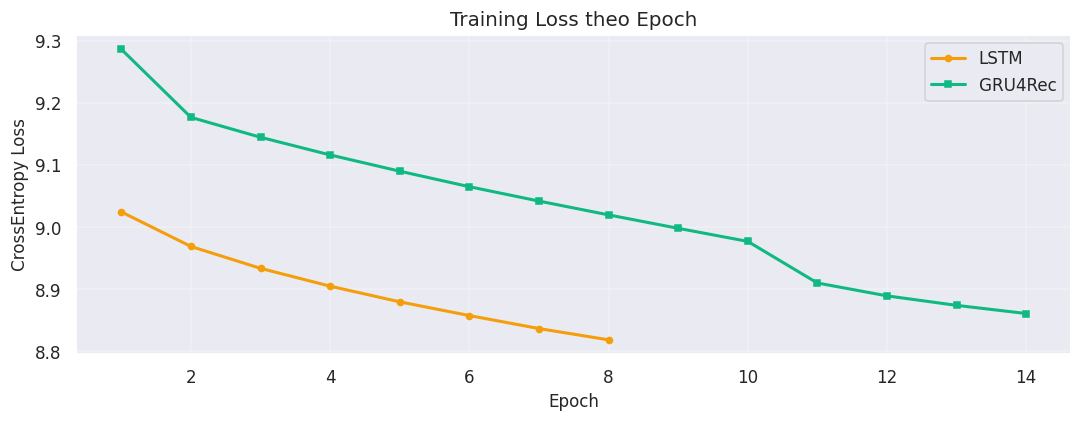

In [ ]:
# Cell 5.7 — Training Curves: Loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lstm_hist['epoch'], lstm_hist['loss'], 'o-',
        label='LSTM', color='#f59e0b', linewidth=2, markersize=4)
ax.plot(gru_hist['epoch'],  gru_hist['loss'],  's-',
        label='GRU4Rec', color='#10b981', linewidth=2, markersize=4)
ax.set_title('Training Loss theo Epoch')
ax.set_xlabel('Epoch'); ax.set_ylabel('CrossEntropy Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/11_loss_curve.png', bbox_inches='tight')
plt.show()

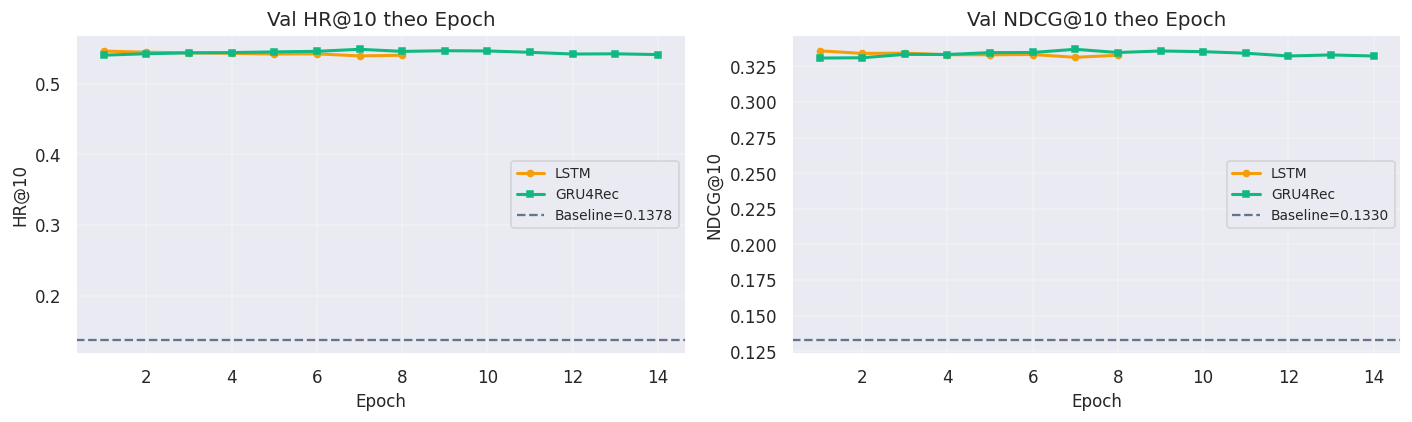

In [ ]:
# Cell 5.8 — Training Curves: HR@10 & NDCG@10
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, col in [
    (axes[0], 'hr10',   'HR@10'),
    (axes[1], 'ndcg10', 'NDCG@10'),
]:
    ax.plot(lstm_hist['epoch'], lstm_hist[metric], 'o-',
            label='LSTM', color='#f59e0b', lw=2, ms=4)
    ax.plot(gru_hist['epoch'],  gru_hist[metric],  's-',
            label='GRU4Rec', color='#10b981', lw=2, ms=4)
    ax.axhline(baseline_test[col], color='#64748b', ls='--', lw=1.5,
               label=f'Baseline={baseline_test[col]:.4f}')
    ax.set_title(f'Val {col} theo Epoch')
    ax.set_xlabel('Epoch'); ax.set_ylabel(col)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/12_metric_curves.png', bbox_inches='tight')
plt.show()

---
# 📈 6. Đánh Giá & So Sánh

In [ ]:
# Cell 6.1 — Bảng so sánh tất cả models
all_results = {
    'Item-KNN Baseline': baseline_test,
    'LSTM'               : lstm_test,
    'GRU4Rec'            : gru_test,
}
metric_cols = [f'{m}@{k}' for m in ['HR','NDCG'] for k in K_LIST]

rows = []
for name, m in all_results.items():
    rows.append({'Model': name, **{k: round(v,4) for k,v in m.items()}})
df_cmp = pd.DataFrame(rows).set_index('Model')

def hl_max(s):
    return ['background-color:#1a3a1a;color:#4ade80;font-weight:bold'
            if v == s.max() else '' for v in s]

display(df_cmp[metric_cols].style.apply(hl_max).format('{:.4f}'))

,HR@5,HR@10,HR@20,NDCG@5,NDCG@10,NDCG@20
Model,,,,,,
Popularity Baseline,0.1378,0.1378,0.1378,0.1330,0.1330,0.1330
LSTM,0.3686,0.4997,0.6412,0.2607,0.3031,0.3388
GRU4Rec,0.3715,0.5046,0.6467,0.2628,0.3059,0.3418


In [ ]:
# Cell 6.2 — % cải thiện so với baseline
print('📈 Improvement vs Item-KNN Baseline:')
print(f'{"":<20} {"HR@5":>8} {"HR@10":>8} {"NDCG@5":>8} {"NDCG@10":>8}')
print('-'*56)
for name in ['LSTM', 'GRU4Rec']:
    m = all_results[name]; b = all_results['Popularity Baseline']
    improvements = []
    for metric in ['HR@5','HR@10','NDCG@5','NDCG@10']:
        imp = (m[metric]-b[metric])/b[metric]*100 if b[metric] > 0 else 0
        improvements.append(f'+{imp:.1f}%')
    print(f'{name:<20}', '  '.join(f'{x:>8}' for x in improvements))

📈 Improvement vs Popularity Baseline:
                         HR@5    HR@10   NDCG@5  NDCG@10
--------------------------------------------------------
LSTM                  +167.4%   +262.6%    +95.9%   +127.8%
GRU4Rec               +169.5%   +266.1%    +97.5%   +129.9%


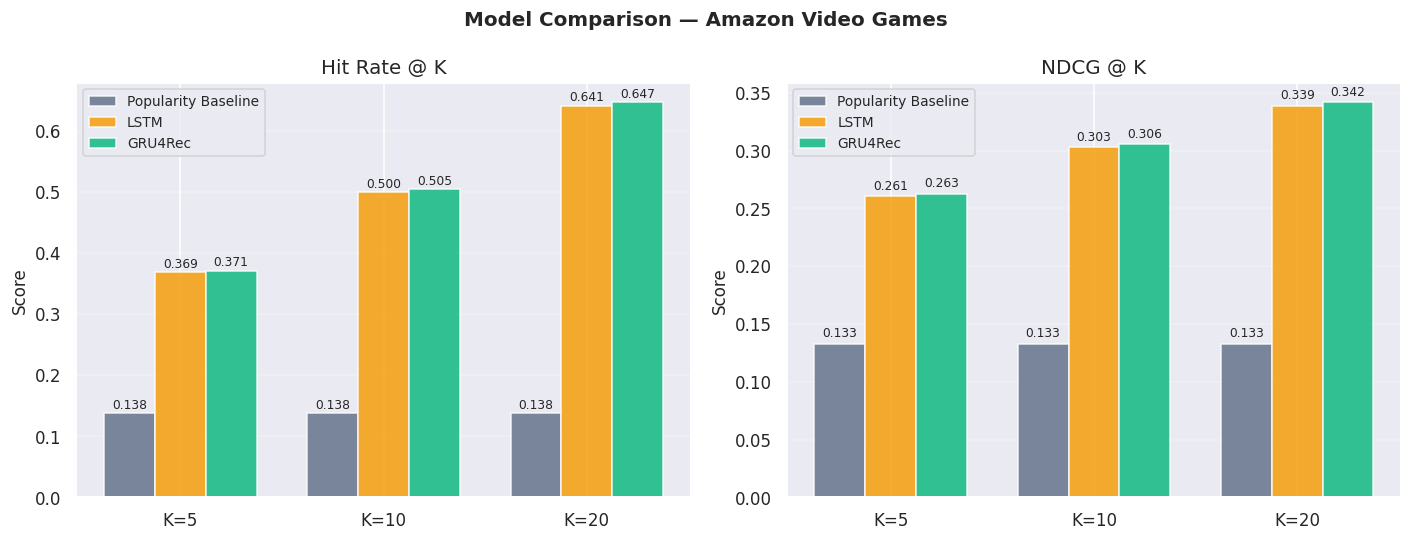

In [ ]:
# Cell 6.3 — Bar chart so sánh
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x    = np.arange(len(K_LIST))
w    = 0.25
cols = ['#64748b', '#f59e0b', '#10b981']
names = list(all_results.keys())

for ax, prefix, title in [
    (axes[0], 'HR',   'Hit Rate @ K'),
    (axes[1], 'NDCG', 'NDCG @ K'),
]:
    for i, (name, col) in enumerate(zip(names, cols)):
        vals = [all_results[name][f'{prefix}@{k}'] for k in K_LIST]
        bars = ax.bar(x + i*w, vals, w, label=name,
                      color=col, alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.003,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x+w); ax.set_xticklabels([f'K={k}' for k in K_LIST])
    ax.set_title(title); ax.set_ylabel('Score')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison — Amazon Video Games', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/13_model_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
# Cell 6.4 — Phân tích case study: xem prediction cụ thể
@torch.no_grad()
def show_recommendations(model, user_id, top_k=10):
    model.eval()
    hist   = train_data.get(user_id, [])
    target = test_data.get(user_id)

    if len(hist) > MAX_LEN: hist = hist[-MAX_LEN:]
    seq_len = len(hist)
    padded  = [0]*(MAX_LEN-seq_len) + hist

    it_seq = torch.tensor([padded], dtype=torch.long).to(DEVICE)
    sl     = torch.tensor([seq_len], dtype=torch.long).to(DEVICE)
    out    = model.forward(it_seq, sl)
    all_e  = model.embedding.weight[1:].to(DEVICE)
    scores = (out @ all_e.T).squeeze(0).cpu()

    for h in hist: scores[h-1] = -1e9  # mask lịch sử
    _, topk = torch.topk(scores, top_k)

    print(f'User {user_id}')
    print(f'History ({len(hist)} items):')
    for it in hist[-5:]:
        asin = id2item.get(it, '?')
        print(f'  [{it}] {meta.get(asin,{}).get("title",asin)[:55]}')
    print(f'\nGround truth test item: [{target}] '
          f'{meta.get(id2item.get(target,""),{}).get("title","")[:55]}')
    print(f'\nTop-{top_k} Recommendations:')
    for rank, idx in enumerate(topk.tolist(), 1):
        item_id = idx + 1
        asin    = id2item.get(item_id, '?')
        title   = meta.get(asin,{}).get('title', asin)[:55]
        hit     = ' ← ✅ HIT!' if item_id == target else ''
        print(f'  {rank:2}. [{item_id}] {title}{hit}')

# Chạy thử 2 users
sample_users = random.sample(list(test_data.keys()), min(2, len(test_data)))
gru_model.eval()
for uid in sample_users:
    print('='*65)
    show_recommendations(gru_model, uid)
    print()

User 95122
History (4 items):
  [4342] Logitech G5 USB Laser Gaming Mouse w/Adjustable Weight 
  [8751] S.T.A.L.K.E.R.: Shadow of Chernobyl [Download]
  [10480] Sniper Elite V2 [Online Game Code]
  [8963] Battlefield 3 - Playstation 3

Ground truth test item: [10228] Crysis 3 [Instant Access]

Top-10 Recommendations:
   1. [15950] amFilm Tempered Glass Screen Protector for Nintendo Swi
   2. [10342] Grand Theft Auto V: Premium Edition - Xbox One [Digital
   3. [20476] Skyrim VR - PlayStation 4
   4. [20459] Fallout 4 - Xbox One
   5. [9090] PlayStation Plus: 12 Month Membership [Digital Code]
   6. [11269] Battlefield 4 - Playstation 3
   7. [17404] DualShock 4 Wireless Controller for PlayStation 4 - Jet
   8. [11160] PlayStation 4 500GB Console [Old Model][Discontinued]
   9. [11209] Assassin's Creed IV Black Flag - PC
  10. [21057] The Legend of Zelda: Breath of the Wild Master Edition 

User 86027
History (3 items):
  [9435] Just Dance 3
  [21057] The Legend of Zelda: Breath of the 

---
# 💾 7. Lưu Model & Artifacts

In [ ]:
# Cell 7.1 — Lưu model weights
torch.save(lstm_model.state_dict(), 'checkpoints/LSTM_final.pt')
torch.save(gru_model.state_dict(),  'checkpoints/GRU4Rec_final.pt')
print('✅ Đã lưu checkpoints/LSTM_final.pt')
print('✅ Đã lưu checkpoints/GRU4Rec_final.pt')

✅ Đã lưu checkpoints/LSTM_final.pt
✅ Đã lưu checkpoints/GRU4Rec_final.pt


In [ ]:
# Cell 7.2 — Lưu model config + kết quả
model_config = {
    'num_items' : NUM_ITEMS,
    'num_users' : NUM_USERS,
    'emb_dim'   : EMB_DIM,
    'hidden'    : HIDDEN,
    'n_layers'  : N_LAYERS,
    'dropout'   : DROPOUT,
    'max_len'   : MAX_LEN,
    'k_core'    : K_CORE,
    'num_neg'   : NUM_NEG,
}
final_package = {
    'config'   : model_config,
    'results'  : {k: v for k, v in {
        'baseline': baseline_test,
        'lstm'    : lstm_test,
        'gru'     : gru_test,
    }.items()},
    'mappings' : {
        'user2id': user2id, 'item2id': item2id,
        'id2item': id2item, 'meta'   : meta,
    },
    'sequences': {'train': train_data, 'val': val_data, 'test': test_data},
}
with open('checkpoints/model_artifacts.pkl', 'wb') as f:
    pickle.dump(final_package, f)
print('✅ Đã lưu checkpoints/model_artifacts.pkl')
print(f'   Config: {model_config}')

✅ Đã lưu checkpoints/model_artifacts.pkl
   Config: {'num_items': 26354, 'num_users': 98906, 'emb_dim': 64, 'hidden': 128, 'n_layers': 1, 'dropout': 0.2, 'max_len': 50, 'k_core': 5, 'num_neg': 99}


In [ ]:
# Cell 7.3 — Kiểm tra load lại model
gru_reload = GRU4Rec(NUM_ITEMS, EMB_DIM, HIDDEN, N_LAYERS, DROPOUT).to(DEVICE)
gru_reload.load_state_dict(
    torch.load('checkpoints/GRU4Rec_best.pt', map_location=DEVICE, weights_only=True)
)
gru_reload.eval()
m_check = evaluate(gru_reload, test_loader, DEVICE)
print('✅ Model load lại thành công!')
print(f'   HR@10={m_check["HR@10"]:.4f}  NDCG@10={m_check["NDCG@10"]:.4f}')

✅ Model load lại thành công!
   HR@10=0.5046  NDCG@10=0.3059


In [ ]:
# Chạy trên Colab
with open('checkpoints/model_artifacts.pkl', 'rb') as f:
    arts = pickle.load(f)

meta = arts['mappings']['meta']

# Xem thử 5 sản phẩm
for asin, info in list(meta.items())[:5]:
    print(f'ASIN    : {asin}')
    print(f'Title   : {info.get("title", "")}')
    print(f'Img URL : {info.get("img_url", "KHÔNG CÓ")}')
    print(f'Price   : {info.get("price", 0)}')
    print(f'Rating  : {info.get("avg_rating", 0)}')
    print()

ASIN    : B000FH0MHO
Title   : Dash 8-300 Professional Add-On
Img URL : https://m.media-amazon.com/images/I/21DVWE41A0L.jpg
Price   : 0.0
Rating  : 5.0

ASIN    : B00069EVOG
Title   : Phantasmagoria: A Puzzle of Flesh
Img URL : https://m.media-amazon.com/images/I/51pqAznTA9L.jpg
Price   : 0.0
Rating  : 4.1

ASIN    : B00Z9TLVK0
Title   : NBA 2K17 - Early Tip Off Edition - PlayStation 4
Img URL : https://m.media-amazon.com/images/I/51wlIPcf0gL.jpg
Price   : 58.0
Rating  : 4.3

ASIN    : B07SZJZV88
Title   : Nintendo Selects: The Legend of Zelda Ocarina of Time 3D (Renewed)
Img URL : https://m.media-amazon.com/images/I/51raO0wAe8L.jpg
Price   : 37.42
Rating  : 4.9

ASIN    : B002WH4ZJG
Title   : Thrustmaster Elite Fitness Pack for Nintendo Wii
Img URL : https://m.media-amazon.com/images/I/31spO9JKluL.jpg
Price   : 0.0
Rating  : 3.0



In [ ]:
# Lưu tất cả về Drive trước khi tắt
import shutil, os
from google.colab import drive

drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/seqrec_checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

# Lưu checkpoints
for f in os.listdir('checkpoints'):
    shutil.copy(f'checkpoints/{f}', f'{SAVE_DIR}/{f}')
    print(f'✅ {f}')

# Lưu web_export.json
web_export_path = 'outputs/web_export.json'
if os.path.exists(web_export_path):
    shutil.copy(web_export_path, f'{SAVE_DIR}/web_export.json')
    print('✅ web_export.json')
else:
    print(f'⚠️ File {web_export_path} không tồn tại, bỏ qua sao chép.')

print(f'\n📁 Tất cả đã lưu tại: {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ model_artifacts.pkl
✅ GRU4Rec_final.pt
✅ GRU4Rec_best.pt
✅ LSTM_best.pt
✅ LSTM_final.pt
⚠️ File outputs/web_export.json không tồn tại, bỏ qua sao chép.

📁 Tất cả đã lưu tại: /content/drive/MyDrive/seqrec_checkpoints
